# Employee Attrition Prediction
## التنبؤ ببقاء الموظف في الشركة

**الهدف:** بناء نموذج يتنبأ هل الموظف بيترك الشركة (`Attrition = Yes`) أو يبقى (`No`).

**البيانات:** IBM HR Analytics Employee Attrition — 1470 موظف و 35 عمود.

**نوع المسألة:** Binary Classification مع بيانات غير متوازنة (Imbalanced).

## 1. استيراد المكتبات

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, f1_score, precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. تحميل البيانات

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
print("Missing values:", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())

Missing values: 0
Duplicated rows: 0


## 3. استكشاف البيانات (EDA)
### 3.1 توزيع المتغير الهدف

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


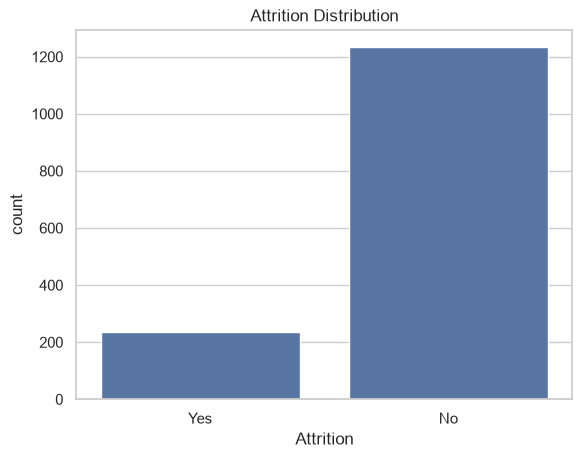

In [5]:
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="Attrition")
plt.title("Attrition Distribution")
plt.show()

> **ملاحظة:** حوالي 16% فقط تركوا الشركة → البيانات **غير متوازنة**.
> لو النموذج قال "No" دايمًا بيجيب Accuracy ≈ 84% وهو ما يفيد بشيء، عشان كذا بنركز على **Recall / F1 / ROC-AUC**.

### 3.2 الأعمدة الفئوية مقابل Attrition

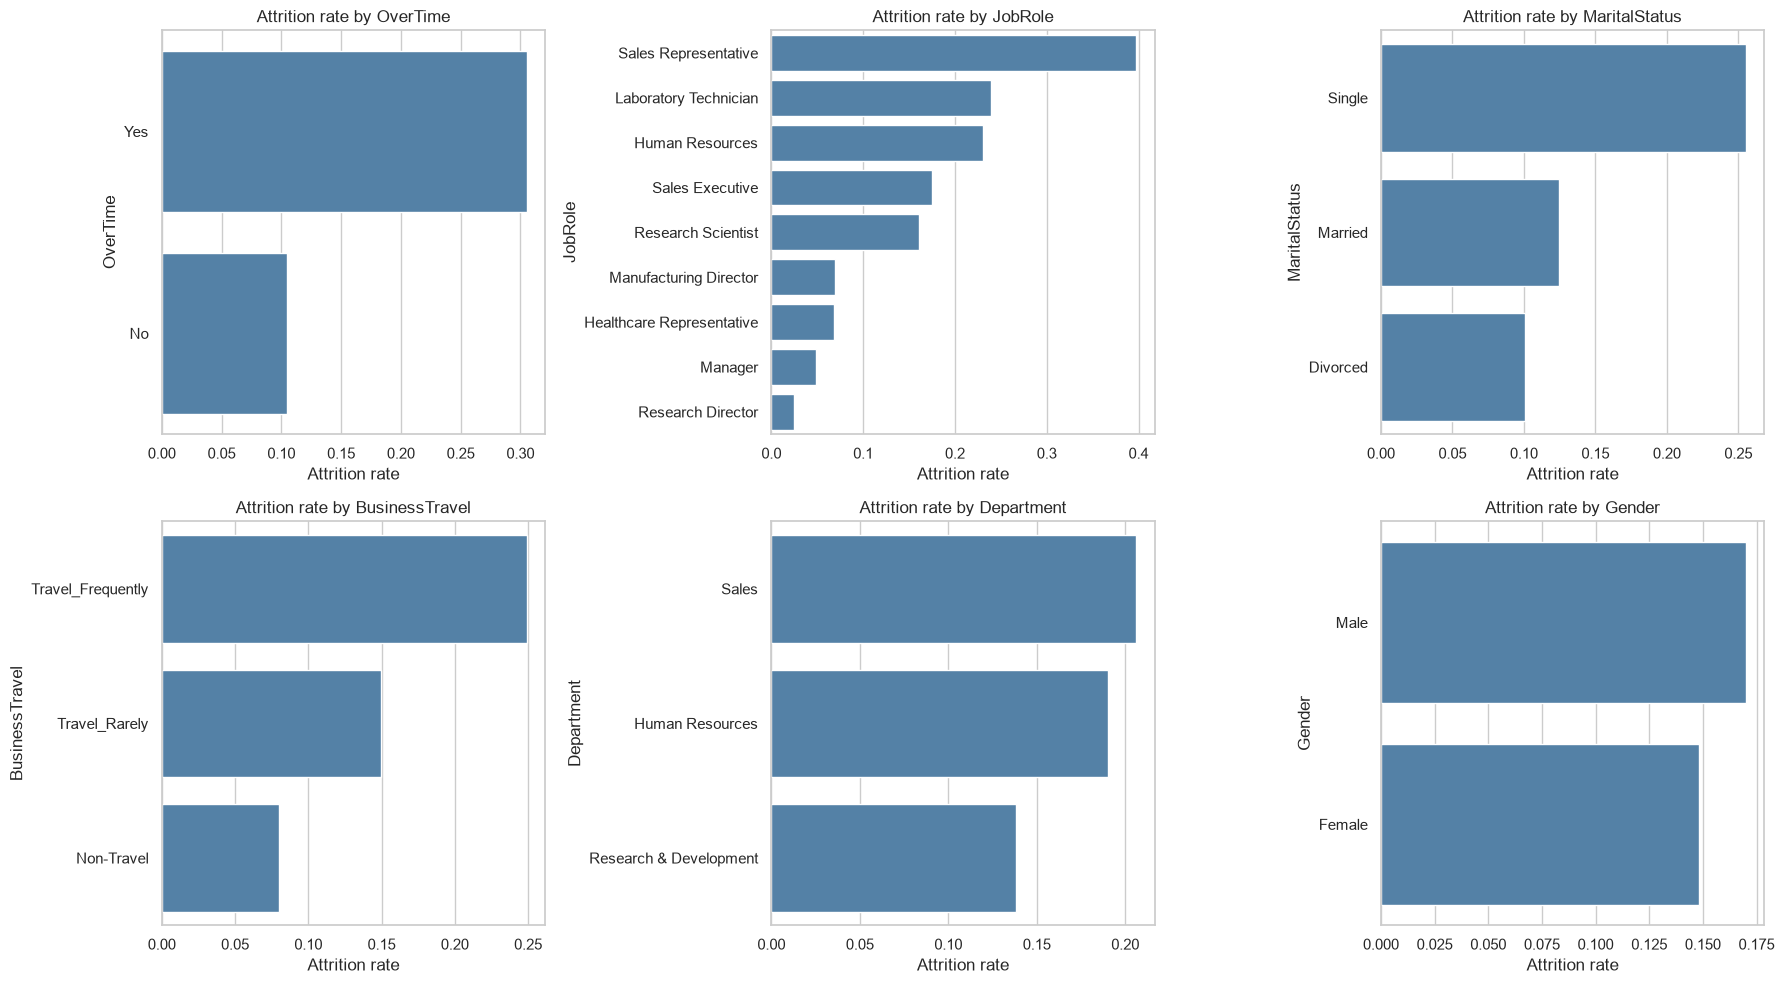

In [6]:
cat_cols_eda = ["OverTime", "JobRole", "MaritalStatus", "BusinessTravel", "Department", "Gender"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, cat_cols_eda):
    rate = df.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="steelblue")
    ax.set_title(f"Attrition rate by {col}")
    ax.set_xlabel("Attrition rate")
plt.tight_layout()
plt.show()

### 3.3 الأعمدة الرقمية مقابل Attrition

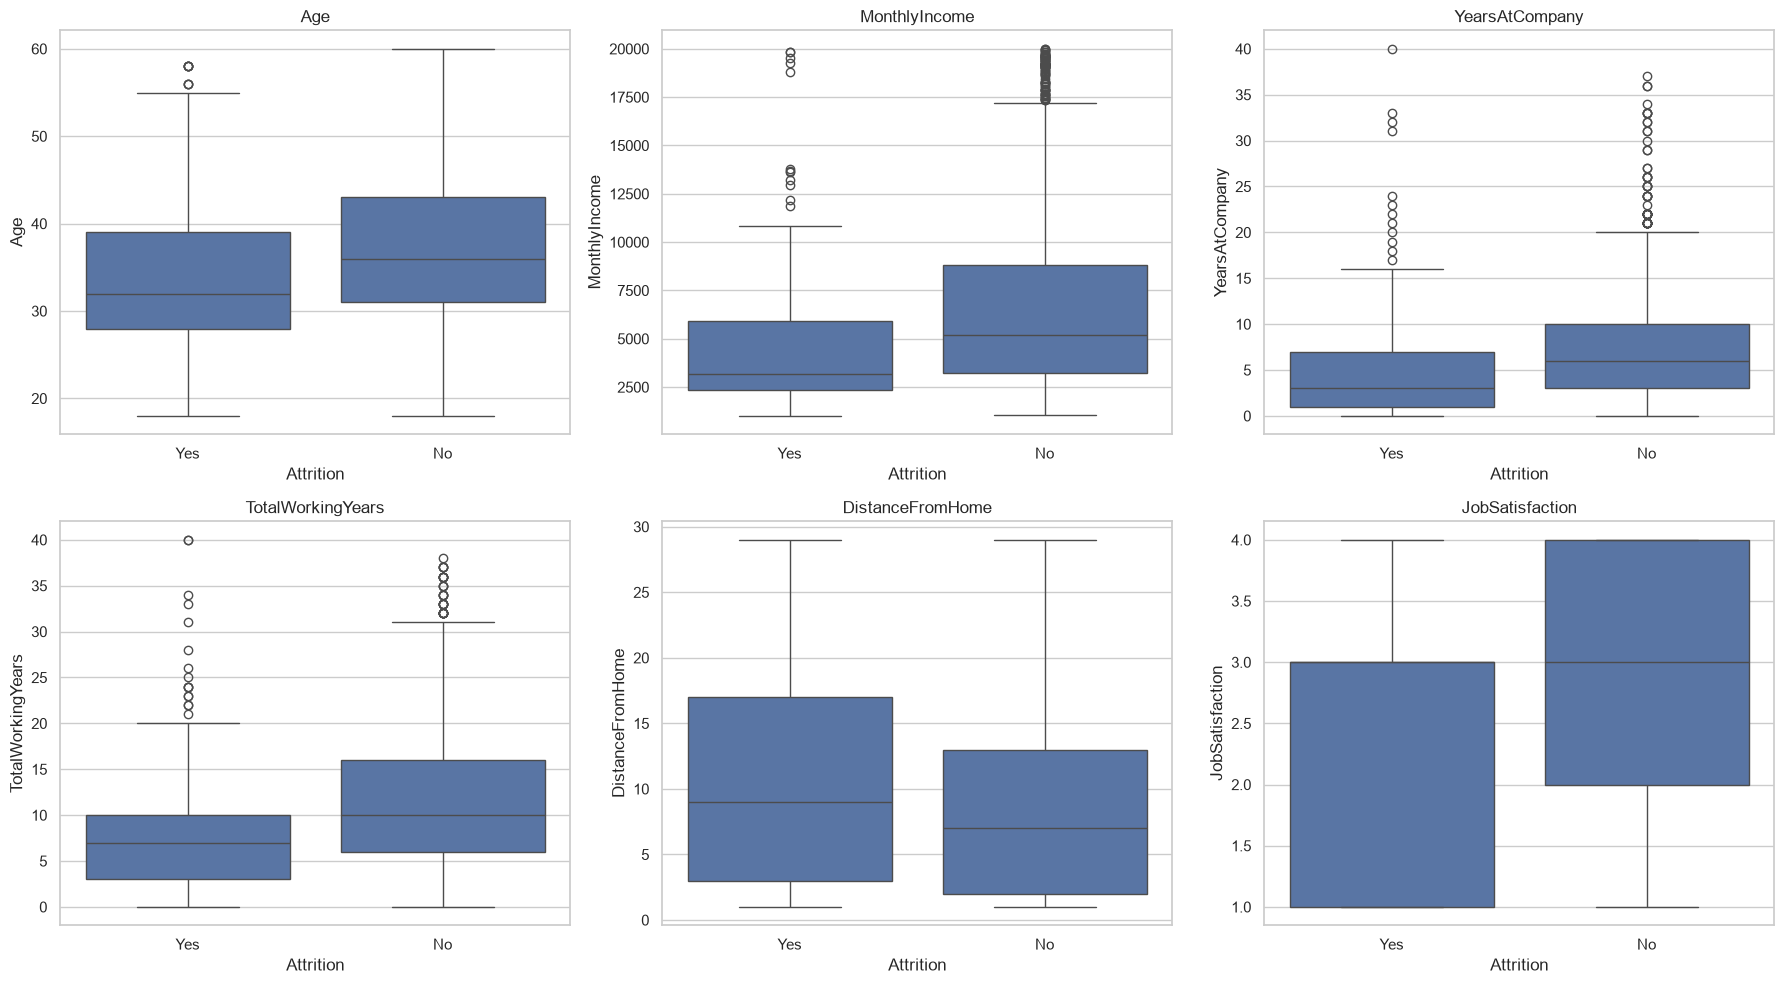

In [7]:
num_cols_eda = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "DistanceFromHome", "JobSatisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, num_cols_eda):
    sns.boxplot(data=df, x="Attrition", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.4 مصفوفة الارتباط

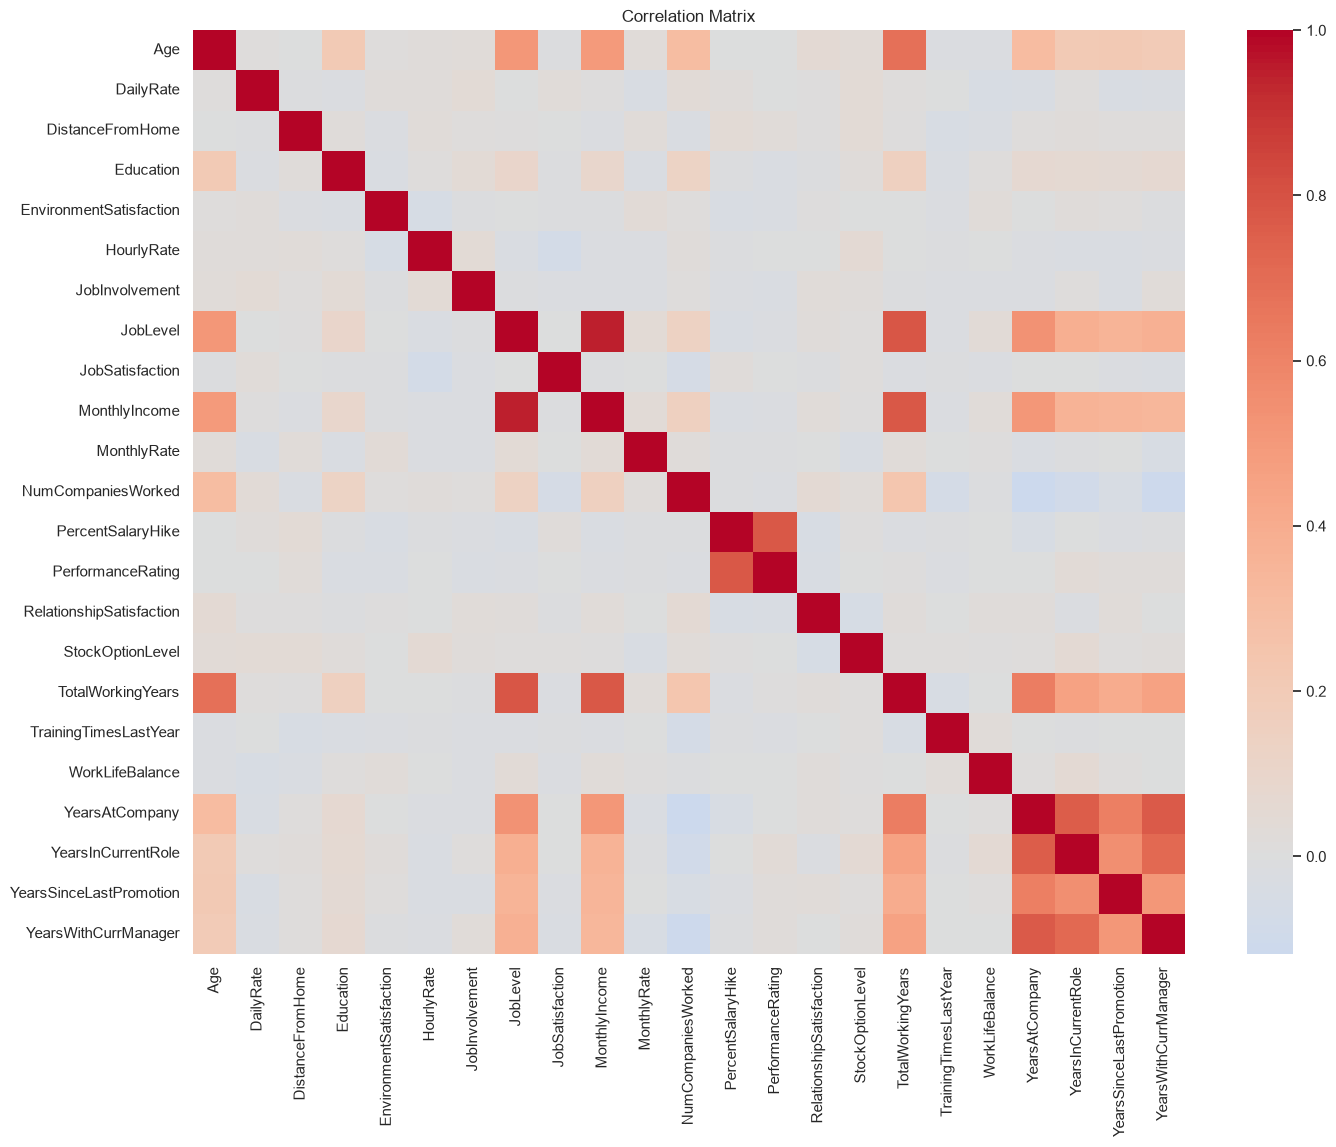

In [8]:
corr = df.select_dtypes("number").drop(columns=["EmployeeCount", "StandardHours", "EmployeeNumber"]).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.show()

## 4. تجهيز البيانات
- حذف الأعمدة اللي ما تفيد: `EmployeeCount`, `StandardHours`, `Over18` (قيمة ثابتة) و `EmployeeNumber` (رقم تعريفي).
- تحويل الهدف إلى 1/0.

In [9]:
drop_cols = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
data = df.drop(columns=drop_cols)

X = data.drop(columns="Attrition")
y = (data["Attrition"] == "Yes").astype(int)

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()
print("Categorical:", cat_cols)
print("Numerical:", len(num_cols), "columns")

Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical: 23 columns


### 4.1 تقسيم البيانات (Stratified)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Attrition rate:", round(y_train.mean(), 3))
print("Test :", X_test.shape,  " Attrition rate:", round(y_test.mean(), 3))

Train: (1176, 30)  Attrition rate: 0.162
Test : (294, 30)  Attrition rate: 0.16


### 4.2 Preprocessing Pipeline

In [11]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_cols),
])

## 5. بناء النماذج
عالجنا عدم التوازن بـ `class_weight="balanced"` (و `scale_pos_weight` في XGBoost) بدل ما نولّد بيانات صناعية.

In [12]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight="balanced",
                                            random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=pos_weight,
                             eval_metric="logloss", random_state=RANDOM_STATE),
}

pipelines = {name: Pipeline([("prep", preprocess), ("model", m)]) for name, m in models.items()}

### 5.1 مقارنة النماذج بـ Cross-Validation (على بيانات التدريب فقط)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "f1", "recall", "precision", "accuracy"]

rows = []
for name, pipe in pipelines.items():
    s = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"Model": name, **{m: s[f"test_{m}"].mean() for m in scoring}})

cv_results = pd.DataFrame(rows).set_index("Model").round(3).sort_values("roc_auc", ascending=False)
cv_results

,roc_auc,f1,recall,precision,accuracy
Model,,,,,
Logistic Regression,0.827,0.492,0.737,0.371,0.753
XGBoost,0.814,0.542,0.532,0.561,0.856
Random Forest,0.810,0.398,0.289,0.684,0.865


## 6. التقييم على بيانات الاختبار

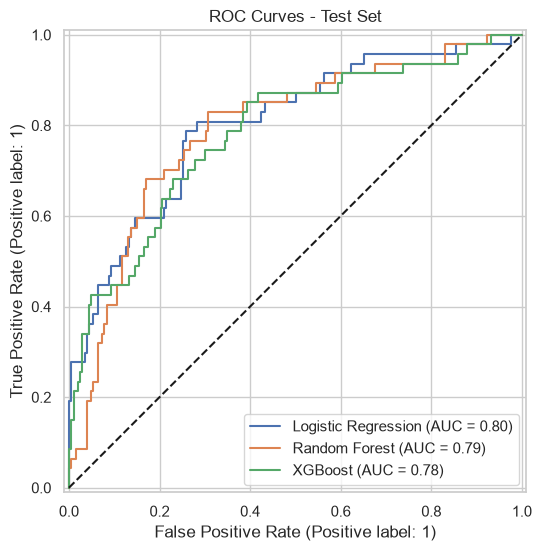

,ROC-AUC,F1
Model,,
Logistic Regression,0.802,0.451
Random Forest,0.791,0.273
XGBoost,0.782,0.438


In [14]:
test_rows = []
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    test_rows.append({"Model": name, "ROC-AUC": roc_auc_score(y_test, proba), "F1": f1_score(y_test, pred)})
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC Curves - Test Set")
plt.show()

pd.DataFrame(test_rows).set_index("Model").round(3)

### 6.1 اختيار أفضل نموذج وضبط العتبة (Threshold)
بدل العتبة الافتراضية 0.5، نختار العتبة اللي تعطي أعلى F1 — ونحسبها من **cross-validation على التدريب** عشان ما نغش من بيانات الاختبار.

In [15]:
best_name = cv_results.index[0]
best_pipe = pipelines[best_name]
print("Best model:", best_name)

oof_proba = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thr[np.argmax(f1s[:-1])]
print("Best threshold:", round(best_thr, 3))

Best model: Logistic Regression


Best threshold: 0.745


              precision    recall  f1-score   support

   Stay (No)       0.89      0.94      0.91       247
 Leave (Yes)       0.54      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.72      0.67      0.69       294
weighted avg       0.84      0.85      0.84       294

ROC-AUC: 0.802


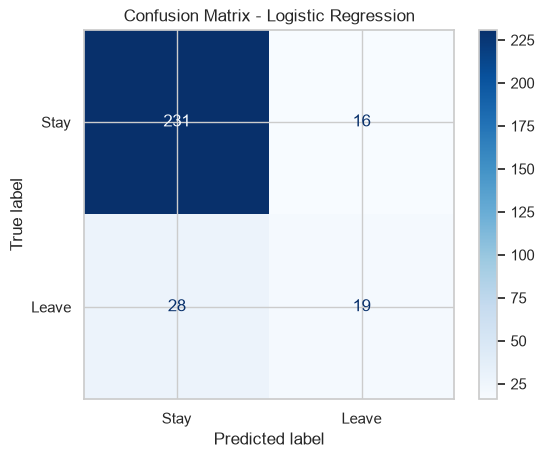

In [16]:
best_pipe.fit(X_train, y_train)
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

print(classification_report(y_test, test_pred, target_names=["Stay (No)", "Leave (Yes)"]))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 3))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["Stay", "Leave"], cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 7. تفسير النموذج — وش أكثر العوامل تأثيرًا؟
نستخدم **Permutation Importance**: نخلط قيم كل عمود ونشوف كم ينزل أداء النموذج.

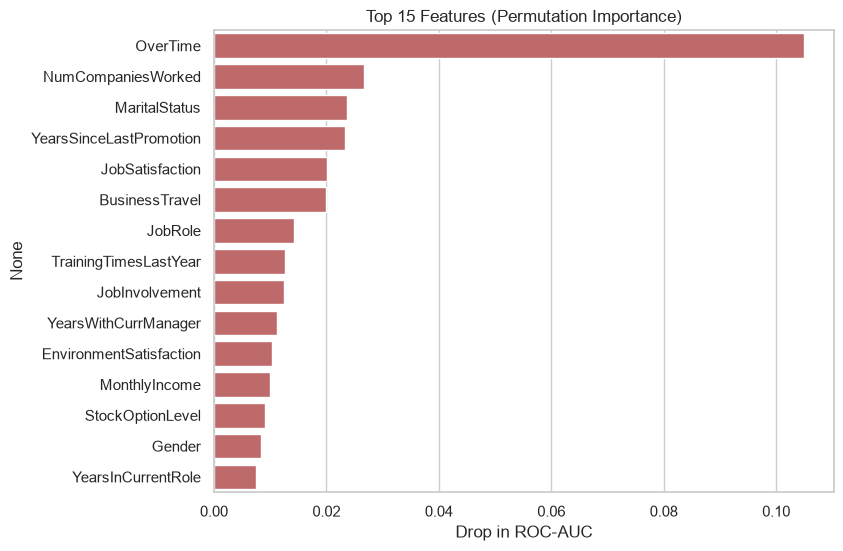

In [17]:
perm = permutation_importance(best_pipe, X_test, y_test, scoring="roc_auc",
                              n_repeats=20, random_state=RANDOM_STATE)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, color="indianred")
plt.title("Top 15 Features (Permutation Importance)")
plt.xlabel("Drop in ROC-AUC")
plt.show()

### 7.1 اتجاه التأثير (معاملات Logistic Regression)

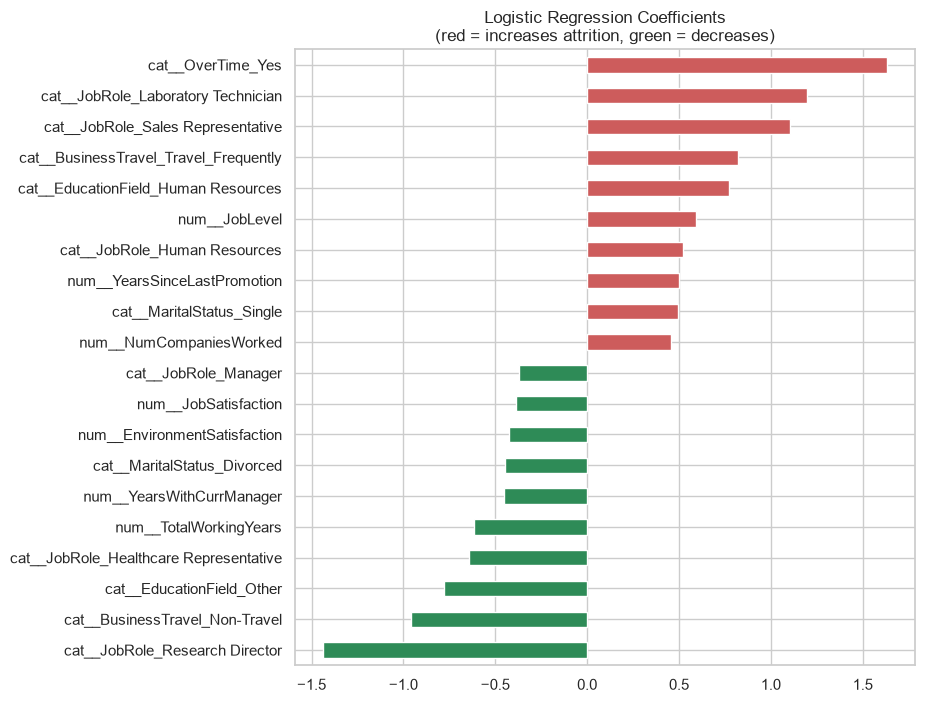

In [18]:
lr_pipe = pipelines["Logistic Regression"]
feat_names = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=feat_names)
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

plt.figure(figsize=(8, 8))
top.plot(kind="barh", color=["seagreen" if v < 0 else "indianred" for v in top])
plt.title("Logistic Regression Coefficients\n(red = increases attrition, green = decreases)")
plt.show()

## 8. حفظ النموذج والتنبؤ لموظف جديد

In [19]:
import joblib
joblib.dump({"model": best_pipe, "threshold": best_thr}, "attrition_model.joblib")

def predict_employee(employee: dict):
    row = pd.DataFrame([employee])[X.columns]
    p = best_pipe.predict_proba(row)[0, 1]
    return {"leave_probability": round(float(p), 3), "prediction": "Leave" if p >= best_thr else "Stay"}

# مثال: نجرب على أول موظف في بيانات الاختبار
sample = X_test.iloc[0].to_dict()
print(predict_employee(sample), "| actual:", "Leave" if y_test.iloc[0] else "Stay")

{'leave_probability': 0.288, 'prediction': 'Stay'} | actual: Stay


## 9. الخلاصة
- البيانات غير متوازنة (~16% Attrition) فاعتمدنا على ROC-AUC و F1 و Recall بدل Accuracy.
- قارنا 3 نماذج بـ Cross-Validation واخترنا الأفضل، وضبطنا العتبة لتحسين اكتشاف الموظفين المعرضين للمغادرة.
- أهم العوامل المؤثرة تظهر في قسم 7 (عادةً: OverTime، الدخل الشهري، سنوات الخبرة، الحالة الاجتماعية، الرضا الوظيفي).
- **التوصية للموارد البشرية:** مراقبة الموظفين اللي عندهم ساعات إضافية كثيرة ودخل منخفض وخبرة قليلة.